<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/OCR_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install Tesseract OCR and Dependencies
We first install the Tesseract system binary, pytesseract, and OpenCV.

In [1]:
!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python Pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


### 2. Preprocessing & OCR Pipeline
To extract text from degraded documents, we can apply denoising and adaptive thresholding to maximize character contrast.

In [2]:
import cv2
import numpy as np
import pytesseract
from PIL import Image

def preprocess_for_ocr(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Upscale the image to make small text legible
    img = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

    # Apply a bilateral filter to remove noise while keeping edges sharp
    denoised = cv2.bilateralFilter(img, 9, 75, 75)

    # Apply adaptive thresholding to binarize the image (converts to pure black and white)
    processed_img = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    return processed_img

def run_ocr_pipeline(image_path):
    # 1. Clean the image
    cleaned_img = preprocess_for_ocr(image_path)

    # 2. Convert array to PIL Image
    pil_img = Image.fromarray(cleaned_img)

    # 3. Apply pytesseract (using PSM 3: fully automatic page segmentation)
    custom_config = r'--oem 3 --psm 3'
    extracted_text = pytesseract.image_to_string(pil_img, config=custom_config)

    return cleaned_img, extracted_text

### 3. Visualizing and Running the OCR Pipeline
Let's generate a synthetic "bad-quality" old document image (with background noise and fading) to demonstrate how our preprocessing improves OCR performance.

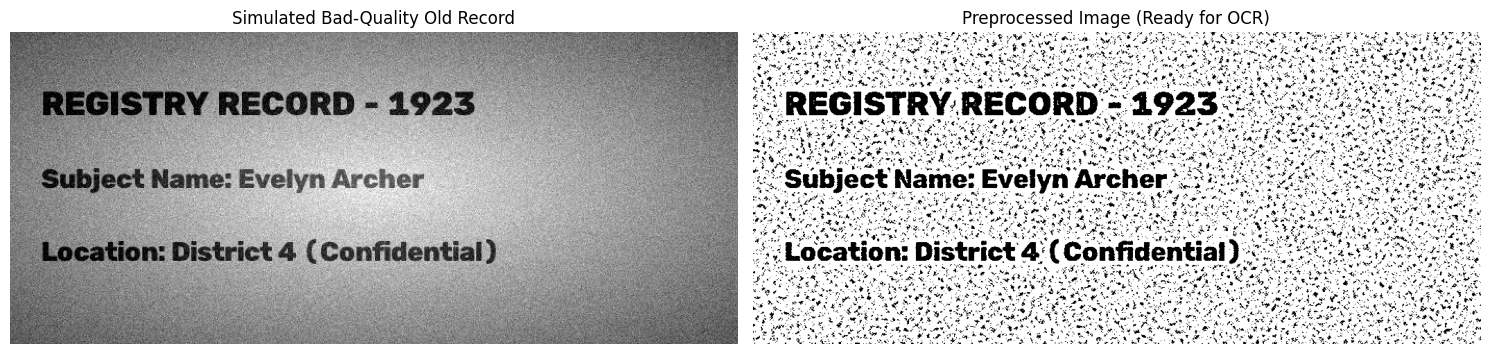


--- Extracted Text from OCR ---
SGISTRY.RECORD. ee

eee es

e: Evelyn.

Location: Di District 4 (




In [3]:
import matplotlib.pyplot as plt
import os

# Define paths
sample_image_path = 'old_record_sample.png'

# Create a mock "degraded" image for demonstration
def create_mock_dirty_record(path):
    # Create a blank white canvas
    img = np.ones((300, 700), dtype=np.uint8) * 230

    # Add mock faded text
    cv2.putText(img, "REGISTRY RECORD - 1923", (30, 80), cv2.FONT_HERSHEY_TRIPLEX, 1.1, (80, 80, 80), 2)
    cv2.putText(img, "Subject Name: Evelyn Archer", (30, 150), cv2.FONT_HERSHEY_COMPLEX, 0.9, (100, 100, 100), 2)
    cv2.putText(img, "Location: District 4 (Confidential)", (30, 220), cv2.FONT_HERSHEY_COMPLEX, 0.9, (90, 90, 90), 2)

    # Simulate paper yellowing / uneven exposure (vignette gradient)
    x = np.linspace(-1, 1, img.shape[1])
    y = np.linspace(-1, 1, img.shape[0])
    x_matrix, y_matrix = np.meshgrid(x, y)
    gradient = np.sqrt(x_matrix**2 + y_matrix**2)
    gradient = cv2.resize(gradient, (img.shape[1], img.shape[0]))
    img = np.clip(img - (gradient * 100), 0, 255).astype(np.uint8)

    # Simulate speckle noise (dirt/stains on paper)
    noise = np.random.normal(0, 15, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Write to file
    cv2.imwrite(path, img)

# Generate the mock record
create_mock_dirty_record(sample_image_path)

try:
    # Run preprocessing and OCR
    cleaned_img, text_output = run_ocr_pipeline(sample_image_path)

    # Plot side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Original mock dirty image
    original_loaded = cv2.imread(sample_image_path)
    axes[0].imshow(cv2.cvtColor(original_loaded, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Simulated Bad-Quality Old Record")
    axes[0].axis('off')

    # Preprocessed black and white text image
    axes[1].imshow(cleaned_img, cmap='gray')
    axes[1].set_title("Preprocessed Image (Ready for OCR)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Output extracted content
    print("\n--- Extracted Text from OCR ---")
    print(text_output if text_output.strip() else "[No text detected. Try tuning the adaptive threshold params!]")

except Exception as e:
    print(f"An error occurred during execution: {e}")